# **Klasifikasi Kualitas Beras**

## **Eksplorasi dan Visualisasi Data**

### **Import Library**

In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

### **Mount Google Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Definisi Path Dataset**

In [3]:
# Path direktori utama
BASE_DIR = '/content/drive/MyDrive/Dataset/rice'

# Definisi nama 4 label
LABELS = ['whole', 'chalky', 'broken', 'discolored']

# Dictionary untuk menyimpan path masing-masing label
label_paths = {lbl: os.path.join(BASE_DIR, lbl) for lbl in LABELS}

# Verifikasi jumlah file gambar di setiap folder label
for lbl, path in label_paths.items():
    if os.path.exists(path):
        image_count = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"Label '{lbl}': Ditemukan {image_count} foto.")
    else:
        print(f"Warning: Path untuk label '{lbl}' tidak ditemukan pada {path}")

Label 'whole': Ditemukan 250 foto.
Label 'chalky': Ditemukan 250 foto.
Label 'broken': Ditemukan 250 foto.
Label 'discolored': Ditemukan 250 foto.


### **Visualisasi Distribusi Dataset**

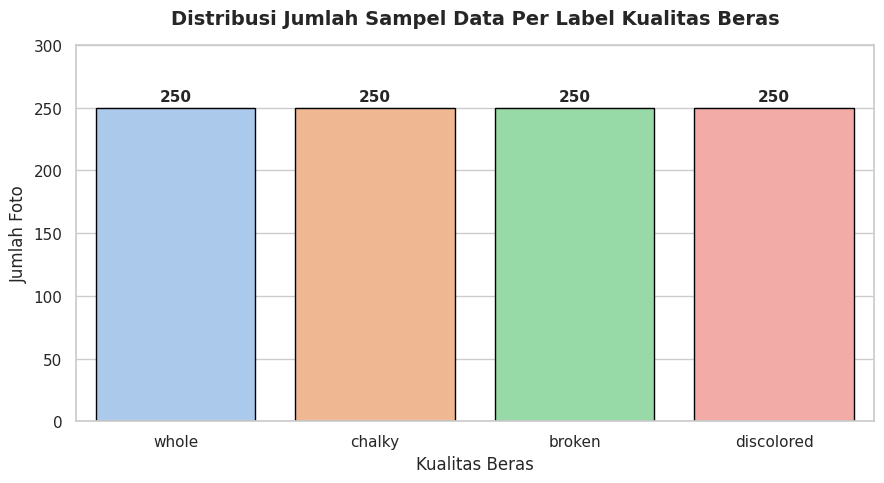

In [4]:
# Menyiapkan data kuantitatif
label_counts = []
for lbl in LABELS:
    path = label_paths[lbl]
    if os.path.exists(path):
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        label_counts.append(count)
    else:
        label_counts.append(0)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=LABELS, y=label_counts, hue=LABELS, palette="pastel", legend=False, edgecolor="black")

# Label nilai di atas setiap bar grafik
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Distribusi Jumlah Sampel Data Per Label Kualitas Beras', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kualitas Beras', fontsize=12)
plt.ylabel('Jumlah Foto', fontsize=12)
plt.ylim(0, max(label_counts) + 50)
plt.tight_layout()
plt.show()

### **Visualisasi Sampel Gambar Beras**

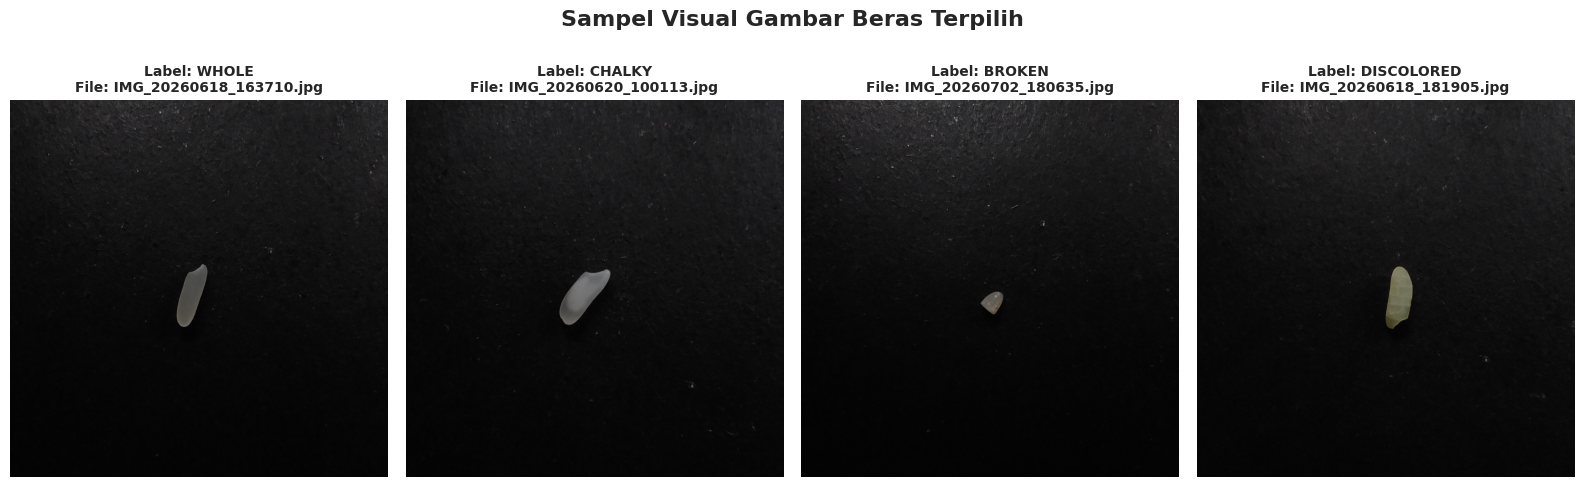

In [5]:
# Sampel gambar secara acak
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, lbl in enumerate(LABELS):
    path = label_paths[lbl]
    if os.path.exists(path):
        # Ambil daftar seluruh file gambar di dalam folder label
        image_files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if image_files:
            # Memilih file secara acak
            random_file = random.choice(image_files)
            img_path = os.path.join(path, random_file)

            # Membaca gambar dan konversi ruang warna dari BGR ke RGB
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Subplot
            axes[i].imshow(img_rgb)
            axes[i].set_title(f"Label: {lbl.upper()}\nFile: {random_file}", fontsize=10, fontweight='bold')
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, 'Folder Kosong', ha='center', va='center')
            axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'Path Tidak Ditemukan', ha='center', va='center')
        axes[i].axis('off')

plt.suptitle('Sampel Visual Gambar Beras Terpilih', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Penyempurnaan Gambar**

### **Filter Penyempurnaan Citra**

In [6]:
def enhance_image(image):
    # Gaussian Blur ringan untuk mereduksi noise sensor kamera
    enhanced_img = cv2.GaussianBlur(image, (3, 3), 0)
    return enhanced_img

## **Preprocessing**

### **Segmentasi Latar Belakang dan Resizing**

In [7]:
def preprocess_grain_image(image, target_size=(224, 224)):
    # Konversi ruang warna ke HSV untuk akurasi segmentasi
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    v_channel = hsv_image[:, :, 2]
    max_v = np.max(v_channel) if np.max(v_channel) > 0 else 1
    h_img, w_img = v_channel.shape[:2]

    # Menyaring objek berdasarkan geometri murni beras
    def find_valid_grain_contour(thresh_value):
        _, binary_mask = cv2.threshold(v_channel, thresh_value, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            return None, binary_mask

        # Urutkan dari area terbesar ke terkecil
        sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)

        for c in sorted_contours:
            area = cv2.contourArea(c)
            if area < 100:
                continue

            x, y, w, h = cv2.boundingRect(c)

            # Filter jika objek memotong > 70% dimensi foto
            if w >= (w_img * 0.70) or h >= (h_img * 0.70):
                continue

            # Filter cek kerapatan konveksitas
            hull = cv2.convexHull(c)
            hull_area = cv2.contourArea(hull)
            solidity = float(area) / hull_area if hull_area > 0 else 0
            if solidity < 0.72:
                continue

            return c, binary_mask

        return None, binary_mask

    # Cari beras menggunakan threshold standar
    thresh_1 = max(int(max_v * 0.35), 50)
    selected_contour, final_mask = find_valid_grain_contour(thresh_1)

    # Jika gagal, gunakan threshold tinggi
    if selected_contour is None:
        thresh_2 = max(int(max_v * 0.55), 80)
        selected_contour, final_mask = find_valid_grain_contour(thresh_2)

    # Pembuatan mask biner murni
    clean_mask = np.zeros_like(final_mask)
    if selected_contour is not None:
        cv2.drawContours(clean_mask, [selected_contour], -1, 255, thickness=cv2.FILLED)
        x, y, w, h = cv2.boundingRect(selected_contour)
    else:
        # Ambil objek yang paling dekat dengan pusat tengah gambar
        contours, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid_fallback = None
        min_dist = float('inf')

        for cnt in contours:
            mx, my, mw, mh = cv2.boundingRect(cnt)
            if mw < (w_img * 0.60) and mh < (h_img * 0.60):
                dist = abs((mx + mw/2) - w_img/2) + abs((my + mh/2) - h_img/2)
                if dist < min_dist:
                    min_dist = dist
                    valid_fallback = cnt

        if valid_fallback is not None:
            cv2.drawContours(clean_mask, [valid_fallback], -1, 255, thickness=cv2.FILLED)
            x, y, w, h = cv2.boundingRect(valid_fallback)
        else:
            x, y, w, h = 0, 0, w_img, h_img

    # Ekstraksi citra biner hitam absolut
    segmented_image = cv2.bitwise_and(image, image, mask=clean_mask if selected_contour is not None or 'valid_fallback' in locals() else final_mask)

    # Potong dan berikan Square Padding 1:1
    grain_crop = segmented_image[y : y + h, x : x + w]
    max_side = max(w, h) if max(w, h) > 0 else 1
    grain_square = np.zeros((max_side, max_side, 3), dtype=np.uint8)
    df_x = (max_side - w) // 2
    df_y = (max_side - h) // 2
    grain_square[df_y : df_y + h, df_x : df_x + w] = grain_crop

    resized_image = cv2.resize(grain_square, target_size, interpolation=cv2.INTER_AREA)
    final_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)

    return final_image

### **Pipeline Ekstraksi Dataset dan Pembagian Data**

In [8]:
# Inisialisasi list untuk menampung matriks gambar dan label numerik
features_data = []
labels_data = []

# Map nama string label ke bentuk indeks integer
label_map = {lbl: idx for idx, lbl in enumerate(LABELS)}

print("Memulai pemrosesan dataset...")

for lbl in LABELS:
    path = label_paths[lbl]
    if os.path.exists(path):
        image_files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        current_count = 0

        for file_name in image_files:
            img_full_path = os.path.join(path, file_name)
            raw_img = cv2.imread(img_full_path)

            if raw_img is not None:
                # Sekuensial filter penyempurnaan citra
                enhanced_img = enhance_image(raw_img)

                # Segmentasi latar belakang hitam absolut & resizing
                processed_img = preprocess_grain_image(enhanced_img, target_size=(224, 224))

                # Normalisasi nilai piksel menjadi skala 0-1 untuk kestabilan konvergensi model
                normalized_img = processed_img / 255.0

                features_data.append(normalized_img)
                labels_data.append(label_map[lbl])
                current_count += 1

        print(f" -> Sukses memproses {current_count} gambar untuk label: {lbl}")

# Konversi struktur data array
X = np.array(features_data, dtype=np.float32)
y = np.array(labels_data, dtype=np.int32)

print("\nBentuk akhir matriks dataset (Shape):")
print(" - Matriks Fitur X:", X.shape)
print(" - Matriks Label y:", y.shape)

# Pembagian data secara Stratified
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nHasil Pembagian Data:")
print(f" -> Total Data Training   : {X_train.shape[0]} sampel")
print(f" -> Total Data Validation : {X_val.shape[0]} sampel\n")

# Verifikasi jumlah sampel per label
for i, lbl in enumerate(LABELS):
    train_count = np.sum(y_train == i)
    val_count = np.sum(y_val == i)
    print(f"Label '{lbl}': Train = {train_count} foto, Val = {val_count} foto.")

# Konversi kembali array yang sudah terbagi ke format TensorFlow
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=len(X_train)).batch(32).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

Memulai pemrosesan dataset...
 -> Sukses memproses 250 gambar untuk label: whole
 -> Sukses memproses 250 gambar untuk label: chalky
 -> Sukses memproses 250 gambar untuk label: broken
 -> Sukses memproses 250 gambar untuk label: discolored

Bentuk akhir matriks dataset (Shape):
 - Matriks Fitur X: (1000, 224, 224, 3)
 - Matriks Label y: (1000,)

Hasil Pembagian Data:
 -> Total Data Training   : 800 sampel
 -> Total Data Validation : 200 sampel

Label 'whole': Train = 200 foto, Val = 50 foto.
Label 'chalky': Train = 200 foto, Val = 50 foto.
Label 'broken': Train = 200 foto, Val = 50 foto.
Label 'discolored': Train = 200 foto, Val = 50 foto.


### **Visualisasi Hasil Preprocessing**

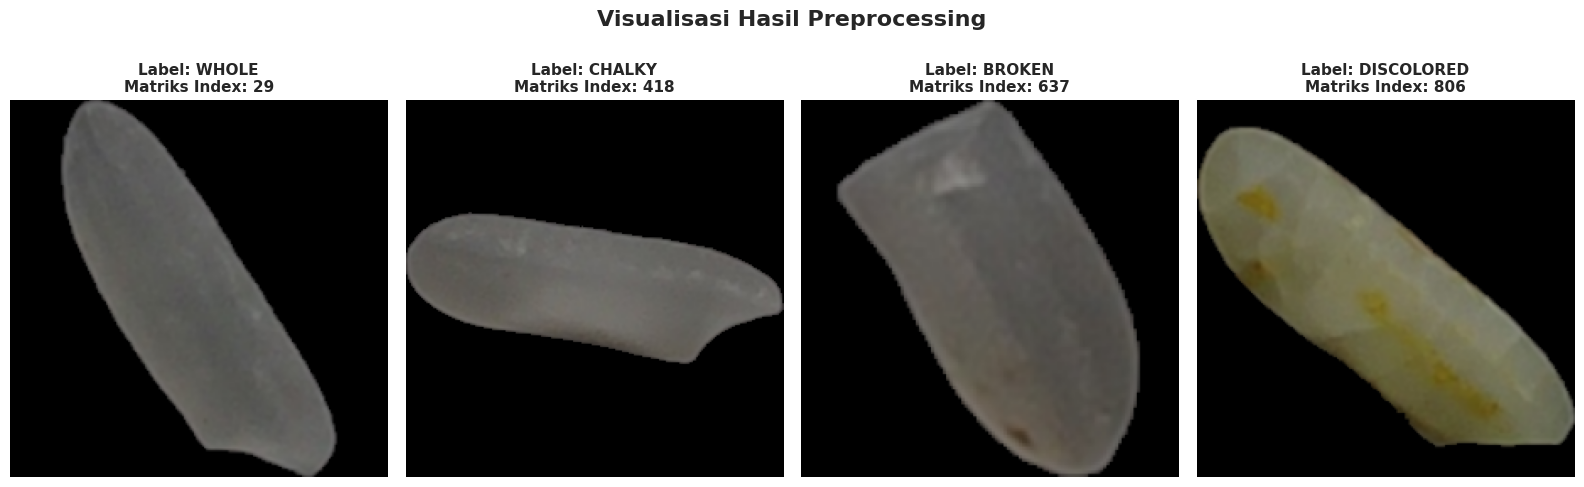

In [9]:
# Komparasi hasil preprocessing
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, lbl in enumerate(LABELS):
    # Mencari seluruh indeks matriks yang memiliki label
    indices = np.where(y == i)[0]

    if len(indices) > 0:
        # Memilih satu indeks secara acak dari label
        random_idx = random.choice(indices)

        # Hasil gambar yang sudah diproses
        axes[i].imshow(X[random_idx])
        axes[i].set_title(f"Label: {lbl.upper()}\nMatriks Index: {random_idx}", fontsize=11, fontweight='bold')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'Data Kosong', ha='center', va='center')
        axes[i].axis('off')

plt.suptitle('Visualisasi Hasil Preprocessing', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **Ekspor Sampel Beras Hasil Preprocessing**

In [10]:
# Nama folder tujuan
SAVE_DIR = '/content/drive/MyDrive/Dataset/rice_preprocessing'
os.makedirs(SAVE_DIR, exist_ok=True)

# Banyak sampel gambar per kategori label
SAMPEL_PER_LABEL = 30

for lbl_idx, lbl_name in enumerate(LABELS):
    # Cari semua indeks posisi gambar yang memiliki label kualitas tersebut
    indices = np.where(y == lbl_idx)[0]

    # Ambil sampel secara acak dari daftar indeks tersebut
    selected_indices = random.sample(list(indices), min(SAMPEL_PER_LABEL, len(indices)))

    for idx in selected_indices:
        # Kembalikan skala nilai piksel dari 0-1 menjadi 0-255 sebelum disimpan
        img_normalized = X[idx]
        img_raw = (img_normalized * 255).astype(np.uint8)

        # Konversi kembali ke BGR
        img_bgr_save = cv2.cvtColor(img_raw, cv2.COLOR_RGB2BGR)

        # Nama file yang unik berdasarkan label dan indeks matriks aslinya
        file_name = f"preprocessed_{lbl_name}_{idx}.png"
        full_save_path = os.path.join(SAVE_DIR, file_name)

        # Eksekusi penyimpanan
        cv2.imwrite(full_save_path, img_bgr_save)
        print(f" -> Berhasil diekspor: {file_name}")

 -> Berhasil diekspor: preprocessed_whole_75.png
 -> Berhasil diekspor: preprocessed_whole_164.png
 -> Berhasil diekspor: preprocessed_whole_53.png
 -> Berhasil diekspor: preprocessed_whole_54.png
 -> Berhasil diekspor: preprocessed_whole_230.png
 -> Berhasil diekspor: preprocessed_whole_109.png
 -> Berhasil diekspor: preprocessed_whole_172.png
 -> Berhasil diekspor: preprocessed_whole_212.png
 -> Berhasil diekspor: preprocessed_whole_46.png
 -> Berhasil diekspor: preprocessed_whole_236.png
 -> Berhasil diekspor: preprocessed_whole_119.png
 -> Berhasil diekspor: preprocessed_whole_12.png
 -> Berhasil diekspor: preprocessed_whole_125.png
 -> Berhasil diekspor: preprocessed_whole_93.png
 -> Berhasil diekspor: preprocessed_whole_92.png
 -> Berhasil diekspor: preprocessed_whole_114.png
 -> Berhasil diekspor: preprocessed_whole_175.png
 -> Berhasil diekspor: preprocessed_whole_176.png
 -> Berhasil diekspor: preprocessed_whole_213.png
 -> Berhasil diekspor: preprocessed_whole_47.png
 -> Berh

## **Pembuatan Model**

### **Konstruksi Arsitektur MobileNetV2**

In [11]:
# Layer pembantu untuk memutar dan membalik gambar secara acak saat training
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(factor=0.5), # Memutar acak dari -180 hingga +180 derajat (Full 360°)
])

# Arsitektur dasar MobileNetV2 dengan pre-trained weights
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Membangun struktur model dengan pipa Augmentasi
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)  # Gambar diputar-putar dulu secara otomatis tiap epoch
x = base_model(x, training=False) # Dilempar ke MobileNetV2
x = GlobalAveragePooling2D()(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(4, activation='softmax')(x)

# Menggabungkan komponen menjadi satu model utuh
model = Model(inputs=inputs, outputs=outputs)

# Ringkasan struktural arsitektur model
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### **Kompilasi Model Deep Learning**

In [12]:
# Mengompilasi model menggunakan Adam Optimizer
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### **Training Model**

In [13]:
EPOCHS = 30

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - accuracy: 0.4775 - loss: 1.1919 - val_accuracy: 0.7400 - val_loss: 0.8427
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.6650 - loss: 0.8300 - val_accuracy: 0.7850 - val_loss: 0.6740
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.7375 - loss: 0.6819 - val_accuracy: 0.8700 - val_loss: 0.5525
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.7663 - loss: 0.6044 - val_accuracy: 0.8950 - val_loss: 0.4757
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.7962 - loss: 0.5633 - val_accuracy: 0.9050 - val_loss: 0.4356
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8300 - loss: 0.5065 - val_accuracy: 0.8750 - val_loss: 0.3990
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8512 - loss: 0.4644 - val_accuracy: 0.9000 - val_loss: 0.3704
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.8350 - loss: 0.4475 - val_accuracy: 0.9000 -

## **Evaluasi**

### **Visualisasi Kurva Akurasi dan Loss**

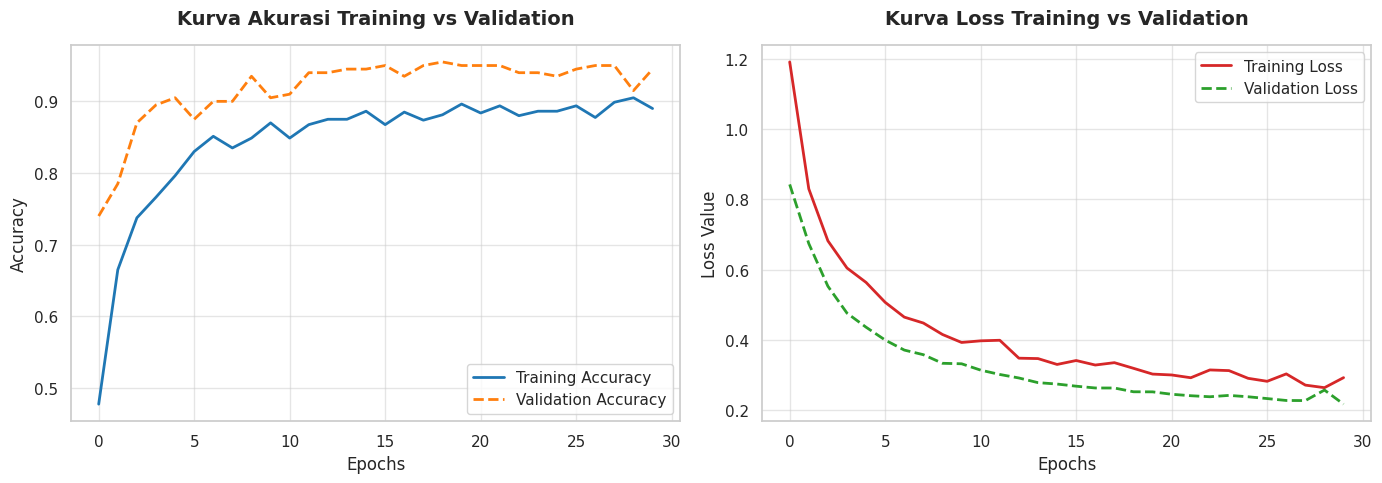

In [14]:
# Nilai historis metrik evaluasi dari objek history training
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))

# Visualisasi perbandingan akurasi model
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('Kurva Akurasi Training vs Validation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.5)

# Visualisasi perbandingan loss model
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#2ca02c', linestyle='--', linewidth=2)
plt.title('Kurva Loss Training vs Validation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

### **Generasi Matriks Evaluasi Klasifikasi Kuantitatif**

In [15]:
# Mengekstrak seluruh gambar asli dan label aktual dari validation dataset
val_images = []
val_labels_actual = []

for images_batch, labels_batch in val_dataset:
    val_images.append(images_batch.numpy())
    val_labels_actual.append(labels_batch.numpy())

# Mengonversi batch menjadi satu array tunggal
X_val = np.concatenate(val_images, axis=0)
y_true = np.concatenate(val_labels_actual, axis=0)

# Memprediksi probabilitas nilai
y_pred_probabilities = model.predict(X_val)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Classification Report
print("\n====== Classification Report Kualitas Beras ======\n")
print(classification_report(y_true, y_pred, target_names=LABELS))

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 336ms/step

====== Classification Report Kualitas Beras ======

              precision    recall  f1-score   support

       whole       0.92      0.92      0.92        50
      chalky       0.92      0.90      0.91        50
      broken       1.00      0.96      0.98        50
  discolored       0.94      1.00      0.97        50

    accuracy                           0.94       200
   macro avg       0.95      0.95      0.94       200
weighted avg       0.95      0.94      0.94       200



### **Visualisasi Heatmap Confusion Matrix**

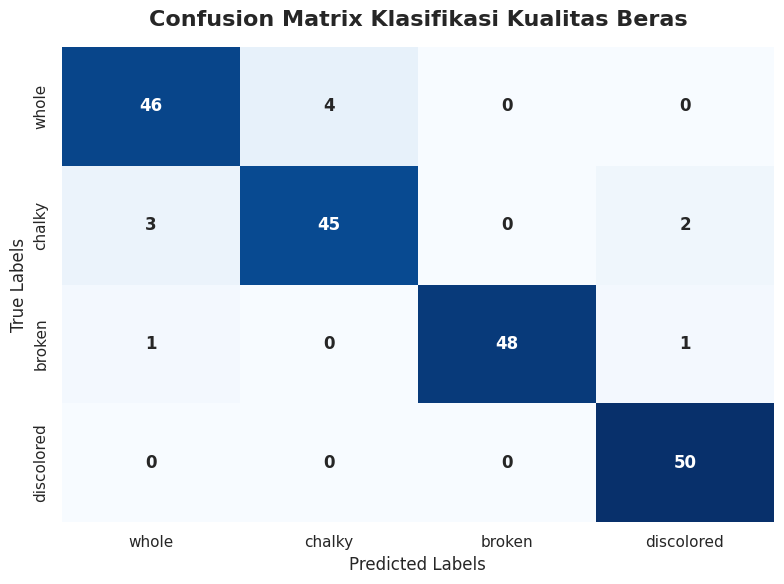

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABELS, yticklabels=LABELS, cbar=False,
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Confusion Matrix Klasifikasi Kualitas Beras', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()
plt.show()

### Penyimpanan Model

In [17]:
model.save('/content/rice_quality.keras')